In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [2]:
df=pd.read_csv('multiple_linear_regression_dataset.csv')

In [3]:
df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [4]:
df.isnull().sum()

,0
age,0
experience,0
income,0


In [5]:
df.corr()

,age,experience,income
age,1.000000,0.615165,0.532204
experience,0.615165,1.000000,0.984227
income,0.532204,0.984227,1.000000


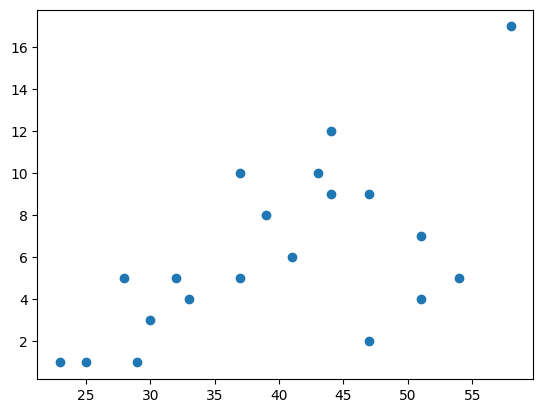

In [6]:
plt.scatter(df['age'],df['experience'])

In [8]:
# Independent and depenedent variables
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [9]:
X

,age,experience
0,25,1
1,30,3
2,47,2
3,32,5
4,43,10
5,51,7
6,28,5
7,33,4
8,37,5
9,39,8


In [11]:
y

,income
0,30450
1,35670
2,31580
3,40130
4,47830
5,41630
6,41340
7,37650
8,40250
9,45150


In [12]:
#train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [17]:
# Importing Standard Scaler
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [18]:
# Importing linear regression model
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [20]:
# Importing cross validation from sklearn
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(lr,X_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [22]:
np.mean(validation_score)

np.float64(-1310885.1997037993)

In [23]:
# Prediction
y_pred=lr.predict(X_test)

In [24]:
# Importing Performanace metrics
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print('MSE:',mse)
print('MAE:',mae)
print('RMSE:',rmse)
print('R2 Score:',r2)

MSE: 2611228.424583983
MAE: 1480.7713503254417
RMSE: 1615.9295852802445
R2 Score: 0.8872690560355568


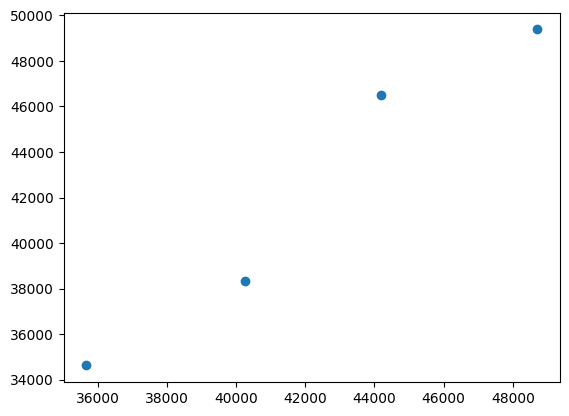

In [26]:
# Assumpations
plt.scatter(y_test,y_pred)

In [27]:
# OLS linear regression
import statsmodels.api as sm

In [28]:
model=sm.OLS(y_train,X_train).fit()

In [29]:
prediction=model.predict(X_test)

In [31]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 income   R-squared (uncentered):                   0.045
Model:                            OLS   Adj. R-squared (uncentered):             -0.091
Method:                 Least Squares   F-statistic:                             0.3297
Date:                Wed, 09 Sep 2026   Prob (F-statistic):                       0.725
Time:                        17:06:36   Log-Likelihood:                         -192.40
No. Observations:                  16   AIC:                                      388.8
Df Residuals:                      14   BIC:                                      390.3
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [32]:
# Printing regression coeffcient
print(lr.coef_)

[-1032.84363333  9374.09783148]
